In [1]:
import torch
import numpy as np 
import matplotlib.pyplot as plt
import time 
import copy
from mpl_toolkits.mplot3d import Axes3D

# choose device. default is 'cpu'
device = 'cpu'

In [2]:
state_dim = 12 # state dimension
control_dim = 4 # dimension of controller
batch_size = 100 # batch size of trajectories to be optimized
t_final = 5.0 # final time
t_initial = 0.0 # initial time

alpha1 = 1.0
alpha2 = 5.0

# number of time steps
nt = int(2.5e2)

# define target at final time
z_target = torch.zeros(batch_size, state_dim)
z_target[:,0:2] = 2.0
z_target[:,3] = 0.5


# create Lagrangian (Running Cost):
def compute_lagrangian(u):
    # assumes u has shape batch_size x control_dim
    batch_size = u.shape[0]
    u = u.view(batch_size, control_dim)
    assert u.shape == (batch_size, control_dim)

    # compute the loss along the feature dimension
    loss = 0.5 * torch.norm(u, dim=1)**2

    assert loss.shape == (batch_size,)
    return loss

def compute_grad_lagrangian(u):
    # assumes u has shape batch_size x control_dim
    batch_size = u.shape[0]
    u = u.view(batch_size, control_dim)
    assert u.shape == (batch_size, control_dim)

    grad_lagrangian_term = u

    return grad_lagrangian_term
    
def compute_G(z): 
    # assumes z has shape batch_size x state_dim
    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)

    # compute the fixed cost G
    G = 0.5*torch.norm(z - z_target, dim=1)**2

    assert G.shape == (batch_size,)
    return G

def compute_f(t, z, u, m=0.5, g=1.0):
    """
    Computes the time derivative of the state vector z = [y1 y2 y3 y4 y5 y6 y7 y8 y9 y10 y11 y12]
    for the quadcopter dynamics problem.

    Arguments:
        t (torch.Tensor or float): Current time (unused in these dynamics).
        z (torch.Tensor): State vector of shape (12,) [y1 y2 y3 y4 y5 y6 y7 y8 y9 y10 y11 y12]
        u (torch.Tensor): Control vector of shape (4, ) [omega_1 omega_2 omega_3 omega_4] 
        m (torch.float64): Mass of quadcopter
        g (torch.float64): Gravitational acceleration

    Returns:
        torch.Tensor: Time derivative of z, i.e. dz/dt, shape (12,).
    """
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)

    # Unpack the control
    omega_1 = u[:,0].view(batch_size, 1)
    omega_2 = u[:,1].view(batch_size, 1)
    omega_3 = u[:,2].view(batch_size, 1)
    omega_4 = u[:,3].view(batch_size, 1)

    # Unpack the state
    y1 = z[:,0].view(batch_size, 1)
    y2 = z[:,1].view(batch_size, 1)
    y3 = z[:,2].view(batch_size, 1)
    y4 = z[:,3].view(batch_size, 1)
    y5 = z[:,4].view(batch_size, 1)
    y6 = z[:,5].view(batch_size, 1)
    y7 = z[:,6].view(batch_size, 1)
    y8 = z[:,7].view(batch_size, 1)
    y9 = z[:,8].view(batch_size, 1)
    y10 = z[:,9].view(batch_size, 1)
    y11 = z[:,10].view(batch_size, 1)
    y12 = z[:,11].view(batch_size, 1)

    # Compute state derivatives
    y1_dot = y7
    y2_dot = y8
    y3_dot = y9
    y4_dot = y10
    y5_dot = y11
    y6_dot = y12
    y7_dot = (omega_1/m)*((torch.sin(y4)*torch.sin(y6) + torch.cos(y4)*torch.sin(y5)*torch.cos(y6)))
    y8_dot = (omega_1/m)*((-torch.cos(y4)*torch.sin(y6) + torch.sin(y4)*torch.sin(y5)*torch.cos(y6)))
    y9_dot = (omega_1/m)*(torch.cos(y5)*torch.cos(y6)) - g
    y10_dot = omega_2
    y11_dot = omega_3
    y12_dot = omega_4

    # Stack into a single tensor
    dz_dt = torch.cat((y1_dot, y2_dot, y3_dot, y4_dot, y5_dot, y6_dot, y7_dot, y8_dot, y9_dot, y10_dot, y11_dot, y12_dot), dim=1)
    assert dz_dt.shape == z.shape 
    return dz_dt

def compute_grad_f_u(t, z, u, m=0.5, g=1.0):
    """
    Computes the gradient of the dynamics f with respect to the control u.

    Arguments:
        t (torch.Tensor or float): Current time (unused in these dynamics).
        z (torch.Tensor): State vector of shape (12,) = [y1 y2 y3 y4 y5 y6 y7 y8 y9 y10 y11 y12]
        u (torch.Tensor): Control vector of shape (4, ) [omega_1 omega_2 omega_3 omega_4] 
        m (torch.float64): Mass of quadcopter
        g (torch.float64): Gravitational acceleration
    """

    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)
    # assert all variables are on the right device
    assert z.device.type == device; assert u.device.type == device

    grad_f_u = torch.zeros(batch_size, control_dim, state_dim)

    # Unpack the state
    y4 = z[:,3].view(batch_size, 1)
    y5 = z[:,4].view(batch_size, 1)
    y6 = z[:,5].view(batch_size, 1)
    
    grad_f_u[:,0,6] = (1.0/m)*((torch.sin(y4)*torch.sin(y6)) + (torch.cos(y4)*torch.sin(y5)*torch.cos(y6))).view(batch_size)
    grad_f_u[:,0,7] = (1.0/m)*((-torch.cos(y4)*torch.sin(y6)) + (torch.sin(y4)*torch.sin(y5)*torch.cos(y6))).view(batch_size)
    grad_f_u[:,0,8] = (1.0/m)*(torch.cos(y5)*torch.cos(y6)).view(batch_size)

    grad_f_u[:,1,9] = 1.0
    grad_f_u[:,2,10] = 1.0
    grad_f_u[:,3,11] = 1.0

    return grad_f_u

def compute_grad_f_z(t, z, u, m=0.5, g=1.0):
    """
    Computes the gradient of the dynamics f with respect to the state vector z.

    Arguments:
        t (torch.Tensor or float): Current time (unused in these dynamics).
        z (torch.Tensor): State vector of shape (12,) = [y1 y2 y3 y4 y5 y6 y7 y8 y9 y10 y11 y12]
        u (torch.Tensor): Control vector of shape (4, ) [omega_1 omega_2 omega_3 omega_4] 
        m (torch.float64): Mass of quadcopter
        g (torch.float64): Gravitational acceleration
    """

    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)
    # assert all variables are on the right device
    assert z.device.type == device; assert u.device.type == device

    grad_f_z = torch.zeros(batch_size, state_dim, state_dim, device=device)

    # Unpack the needed control variable
    omega_1 = u[:,0].view(batch_size, 1)

    # Unpack the needed state variables
    y4 = z[:,3].view(batch_size, 1)
    y5 = z[:,4].view(batch_size, 1)
    y6 = z[:,5].view(batch_size, 1)

    grad_f_z[:,3,6] = ((omega_1/m)*((torch.cos(y4)*torch.sin(y6) - torch.sin(y4)*torch.sin(y5)*torch.cos(y6)))).view(batch_size)
    grad_f_z[:,3,7] = ((omega_1/m)*((torch.sin(y4)*torch.sin(y6) + torch.cos(y4)*torch.sin(y5)*torch.cos(y6)))).view(batch_size)
    grad_f_z[:,4,6] = ((omega_1/m)*((torch.sin(y4)*torch.sin(y6) + torch.cos(y4)*torch.cos(y5)*torch.cos(y6)))).view(batch_size)
    grad_f_z[:,4,7] = ((omega_1/m)*((-torch.cos(y4)*torch.sin(y6) + torch.sin(y4)*torch.cos(y5)*torch.cos(y6)))).view(batch_size)
    grad_f_z[:,4,8] = ((omega_1/m)*(-torch.sin(y5)*torch.cos(y6))).view(batch_size)
    grad_f_z[:,5,6] = ((omega_1/m)*((torch.sin(y4)*torch.cos(y6) - torch.cos(y4)*torch.sin(y5)*torch.sin(y6)))).view(batch_size)
    grad_f_z[:,5,7] = ((omega_1/m)*((-torch.cos(y4)*torch.cos(y6) - torch.sin(y4)*torch.sin(y5)*torch.sin(y6)))).view(batch_size)
    grad_f_z[:,5,8] = ((omega_1/m)*(-torch.cos(y5)*torch.sin(y6))).view(batch_size)
    grad_f_z[:,6:state_dim,0:6] = torch.eye(6,6)

    return grad_f_z

def compute_general_H(t, z, u, p, lagrangian=compute_lagrangian, f=compute_f, device=device):
    """
    Computes the generalized Hamiltonian given by $H = L + p^T f$, and its gradient with respect to u.

    Arguments:
        t (torch.Tensor or float): Current time (unused in these dynamics).
        z (torch.Tensor): State vector of shape (12,) [y1 y2 y3 y4 y5 y6 y7 y8 y9 y10 y11 y12].
        u (torch.Tensor): Control vector of shape (4,) [omega1 omega2 omega3 omega4].
        p (torch.Tensor): Costate vector of shape (12,) = [p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12].
        lagrangian (function): Function that computes the Lagrangian of the system.
        f (function): Function that computes the dynamics of the system.
        device (torch.device): Device on which to perform computations.
    """

    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)
    assert p.shape == (batch_size, state_dim)

    # assert all variables are on the right device
    assert z.device.type == device; assert u.device.type == device; assert p.device.type == device

    f_val = f(t, z, u)
    assert f_val.shape == z.shape

    L_val = lagrangian(u)
    assert L_val.shape == (batch_size,)

    inner_product = torch.sum(p * f_val, dim=1) 
    assert inner_product.shape == (batch_size,)

    H_val = L_val + torch.sum(p * f_val, dim=1)
    assert H_val.shape == (batch_size,)

    return H_val

def compute_grad_H_u(t, z, u, p, lagrangian=compute_lagrangian, f=compute_f, device=device):
    """
    Computes the gradient of Hamiltonian given by $H = L + p^T f$ with respect to the controller u.
    """

    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)
    assert p.shape == (batch_size, state_dim)
    # assert all variables are on the right device
    assert z.device.type == device; assert u.device.type == device; assert p.device.type == device

    # compute gradient
    grad_term1 = compute_grad_lagrangian(u)
    assert grad_term1.shape == u.shape

    grad_f_u_term = compute_grad_f_u(t, z, u)
    assert grad_f_u_term.shape == (batch_size, control_dim, state_dim)

    p = p.unsqueeze(-1) # p now has shape batch_size x state_dim x 1 (this is needed for batch matrix multiplication over samples)
    grad_term2 = torch.bmm(grad_f_u_term, p).view(batch_size, control_dim) # for each sample, multiplies grad_f_u_term * p
    assert grad_term2.shape == u.shape

    grad_H_u_val = grad_term1 + grad_term2

    return grad_H_u_val

def compute_grad_H_z(t, z, u, p, lagrangian=compute_lagrangian, f=compute_f, device=device):
    """
    Computes the gradient of Hamiltonian given by $H = L + p^T f$ with respect to the state z.
    """

    batch_size = z.shape[0]
    assert z.shape == (batch_size, state_dim)
    assert u.shape == (batch_size, control_dim)
    assert p.shape == (batch_size, state_dim)
    # assert all variables are on the right device
    assert z.device.type == device; assert u.device.type == device; assert p.device.type == device

    grad_f_z_term = compute_grad_f_z(t, z, u)
    assert grad_f_z_term.shape == (batch_size, state_dim, state_dim)

    p = p.unsqueeze(-1) # p now has shape batch_size x state_dim x 1 (this is needed for batch matrix multiplication over samples)
    output = torch.bmm(grad_f_z_term, p).view(batch_size, state_dim) # for each sample, multiplies grad_f_z_term * p
    assert output.shape == z.shape

    return output

def compute_loss(u, z0, nt, f=compute_f, alpha1 = alpha1, alpha2 = alpha2):
    # assumes u has shape batch_size x control_dim x nt
    # assumes z0 has shape batch_size x state_dim

    assert z0.shape == (batch_size, state_dim)
    assert nt > 0
    assert device == z0.device.type # make sure all variables are on the right device
    
    running_cost = 0.

    z = z0
    h = (t_final - t_initial)/nt
    ti = 0.0 * torch.ones(1, device=device)

    # compute loss using RK4 method
    if torch.is_tensor(u):
        assert nt == u.shape[2]
        for i in range(nt):
            current_u = u[:,:,i].view(batch_size, control_dim)
            K1 = f(ti, z, current_u)
            K2 = f(ti + 0.5*h, z + 0.5*h*K1, current_u)
            K3 = f(ti + 0.5*h, z + 0.5*h*K2, current_u)
            K4 = f(ti + h, z + h*K3, current_u)
            z = z + (h/6.0)*(K1 + 2.0*K2 + 2.0*K3 + K4)
            ti = ti + h
            running_cost = running_cost + h*compute_lagrangian(current_u)
            
    elif hasattr(u, 'forward'):
        for i in range(nt):
            current_u = u(z, ti).view(batch_size, control_dim)
            K1 = f(ti, z, current_u)
            K2 = f(ti + 0.5*h, z + 0.5*h*K1, current_u)
            K3 = f(ti + 0.5*h, z + 0.5*h*K2, current_u)
            K4 = f(ti + h, z + h*K3, current_u)
            z = z + (h/6.0)*(K1 + 2.0*K2 + 2.0*K3 + K4)
            ti = ti + h
            running_cost = running_cost + h*compute_lagrangian(current_u)

    temp_final_cost = compute_G(z)
    assert temp_final_cost.shape == (batch_size,)
    terminal_cost = torch.mean(temp_final_cost)

    assert running_cost.shape == (batch_size,)
    running_cost = torch.mean(running_cost)

    total_cost = alpha1 * running_cost + alpha2 * terminal_cost

    return total_cost, running_cost, terminal_cost

In [3]:
def sample_initial_condition(batch_size, state_dim, device=device):
    """
    Generates a batch of initial conditions for the 3D linear tangent steering problem.
    """
    z0 = 1e-2*torch.randn(batch_size, state_dim, device=device)
    z0[:,0:3] = 0.0
    return z0

z0 = sample_initial_condition(batch_size, state_dim, device=device)
u0 = torch.randn(batch_size, control_dim, nt, device=device)

In [4]:
z0.device.type == device

True

### Plotting Functions


In [5]:
u_true = torch.randn(batch_size, control_dim, nt, requires_grad=True)
# z0 = torch.zeros(batch_size, state_dim)
# z0[0,:] = torch.zeros(state_dim)
# z0[1,:] = torch.zeros(state_dim); z0[1,0] = 1e-1; z0[1,1] = 1e-1

def generate_trajectory(u, z0, nt, return_full_trajectory=False):

    # assume u has shape batch_size x control_dim x nt
    # assume z0 has shape batch_size x state_dim
    z = torch.zeros(batch_size, state_dim, nt+1)

    z[:,:,0] = z0
    
    h = (t_final - t_initial)/nt
    ti = 0.0

    for i in range(nt):
        if torch.is_tensor(u):
            assert nt == u.shape[2]
            current_u = u[:,:,i].view(batch_size, control_dim)
        elif hasattr(u, 'forward'):
            current_u = u(z[:,:,i], ti).view(batch_size, control_dim)
        z[:,:,i+1] = z[:,:,i] + h*compute_f(ti, z[:,:,i], current_u)
        ti = ti + h

    if return_full_trajectory:
        return z
    else:
        return z[:,:,-1]

In [6]:
def plot_position_trajectories(z_traj, z_target, title_str, plot_velocity=False, pos_range = [-2.0,2.0], vel_range = [-2.0,2.0]):
    """
    Plots 3D trajectories from a torch tensor of shape (batch_size, 6, nt),
    where the first three dimensions correspond to positions (x, y, z).

    Args:
        z_traj (torch.Tensor): Input tensor of shape (batch_size, 6, nt)
    """
    batch_size, _, nt = z_traj.shape

    # Extract position coordinates
    positions = z_traj[:, :3, :]  # Shape: (batch_size, 3, nt)

    # Create a 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d', xlim=pos_range, ylim=pos_range, zlim=pos_range)

    # Plot the initial conditions

    # Plot each trajectory
    for i in range(batch_size):
        x, y, z = positions[i]  # Extract individual trajectory
        # ax.plot(x.numpy(), y.numpy(), z.numpy(), label=f'Trajectory {i+1}', linewidth=3)
        ax.plot(x.numpy(), y.numpy(), z.numpy(), linewidth=3)

        # Mark the initial condition with a red dot
        ax.scatter(x[0].item(), y[0].item(), z[0].item(), color='blue', marker='o', s= 30, label='initial condition' if i == 0 else None)

        # Mark the target condition with a red dot
        ax.scatter(z_target[i,0].item(), z_target[i,1].item(), z_target[i,2].item(), color='red', marker='x', s=50, label='target' if i == 0 else None)

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_title(title_str)
    ax.legend()

    plt.show()

    if plot_velocity:
        # Extract position coordinates
        velocities = z_traj[:, 6:9, :]  # Shape: (batch_size, 3, nt)

        # Create a 3D plot
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d', xlim=vel_range, ylim=vel_range, zlim=vel_range)


        # Plot the initial conditions

        # Plot each trajectory
        for i in range(batch_size):
            x, y, z = velocities[i]  # Extract individual trajectory
            # ax.plot(x.numpy(), y.numpy(), z.numpy(), label=f'Trajectory {i+1}', linewidth=3)
            ax.plot(x.numpy(), y.numpy(), z.numpy(), linewidth=3)

            # Mark the initial condition with a red dot
            ax.scatter(x[0].item(), y[0].item(), z[0].item(), color='blue', marker='o', s= 30, label='initial condition' if i == 0 else None)
            # Mark the target condition with a red dot
            ax.scatter(z_target[i,3].item(), z_target[i,4].item(), z_target[i,5].item(), color='red', marker='x', s=50, label='target' if i == 0 else None)
 
        # plot target velocity

        ax.set_xlabel('X Velocity')
        ax.set_ylabel('Y Velocity')
        ax.set_zlabel('Z Velocity')
        ax.set_title('Velocity Trajectories')
        ax.legend()

        plt.show()

## Initial Guess For Direct Transcription (No INN)

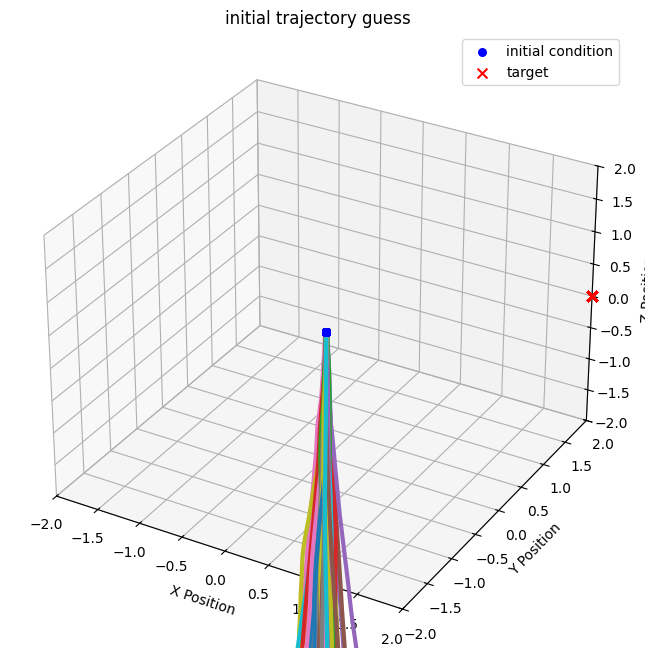

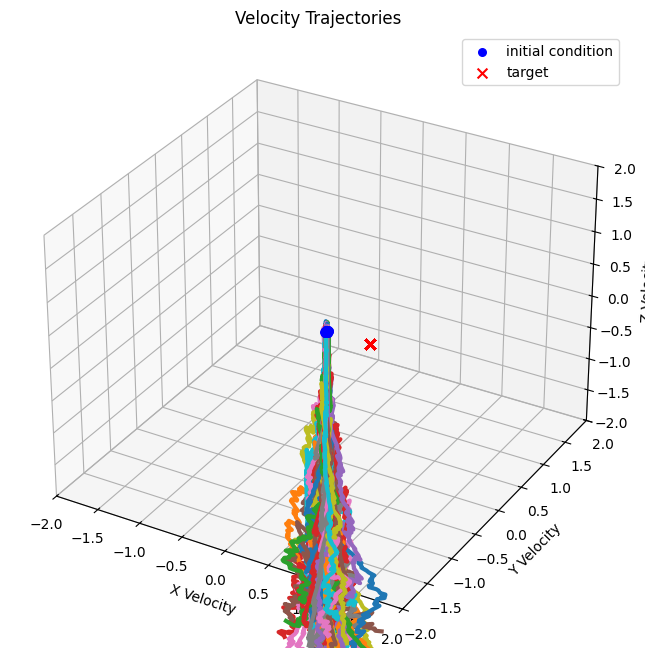

In [8]:
z_traj = generate_trajectory(u_true, z0, nt, return_full_trajectory=True)

plot_position_trajectories(z_traj.detach(), z_target, 'initial trajectory guess', plot_velocity=True)

## Direct Transcription Code (No INN)


In [9]:
# update u using Adam
optimizer = torch.optim.Adam([u_true], lr=1e-2)
max_iters = int(5e2)

for i in range(1, max_iters+1):

    iter_time = time.time()
    optimizer.zero_grad()
    loss, running_cost, terminal_cost = compute_loss(u_true, z0, nt)
    loss.backward()
    optimizer.step()

    end_time = time.time()

    iter_time = end_time - iter_time

    # compute gradient norm 
    grad_norm = torch.norm(u_true.grad)

    if i % 1 == 0:
        # print in %1.3e format
        print("iter %d, loss %.3e, grad %.3e, L %.3e, G %.3e, time %.3e" % (i, loss.item(), grad_norm.item(), running_cost.item(), terminal_cost.item(), iter_time))

iter 1, loss 5.013e+02, grad 1.253e+01, L 9.988e+00, G 9.827e+01, time 9.461e-01
iter 2, loss 4.823e+02, grad 1.229e+01, L 9.970e+00, G 9.446e+01, time 9.296e-01
iter 3, loss 4.637e+02, grad 1.205e+01, L 9.952e+00, G 9.074e+01, time 9.044e-01
iter 4, loss 4.456e+02, grad 1.180e+01, L 9.935e+00, G 8.714e+01, time 9.273e-01
iter 5, loss 4.281e+02, grad 1.155e+01, L 9.917e+00, G 8.364e+01, time 1.032e+00
iter 6, loss 4.112e+02, grad 1.130e+01, L 9.900e+00, G 8.026e+01, time 9.078e-01
iter 7, loss 3.949e+02, grad 1.106e+01, L 9.883e+00, G 7.701e+01, time 1.090e+00
iter 8, loss 3.792e+02, grad 1.082e+01, L 9.866e+00, G 7.386e+01, time 9.706e-01
iter 9, loss 3.640e+02, grad 1.058e+01, L 9.849e+00, G 7.084e+01, time 1.053e+00
iter 10, loss 3.494e+02, grad 1.035e+01, L 9.832e+00, G 6.792e+01, time 1.096e+00
iter 11, loss 3.353e+02, grad 1.013e+01, L 9.816e+00, G 6.510e+01, time 9.186e-01
iter 12, loss 3.216e+02, grad 9.908e+00, L 9.799e+00, G 6.236e+01, time 9.106e-01
iter 13, loss 3.083e+02, 

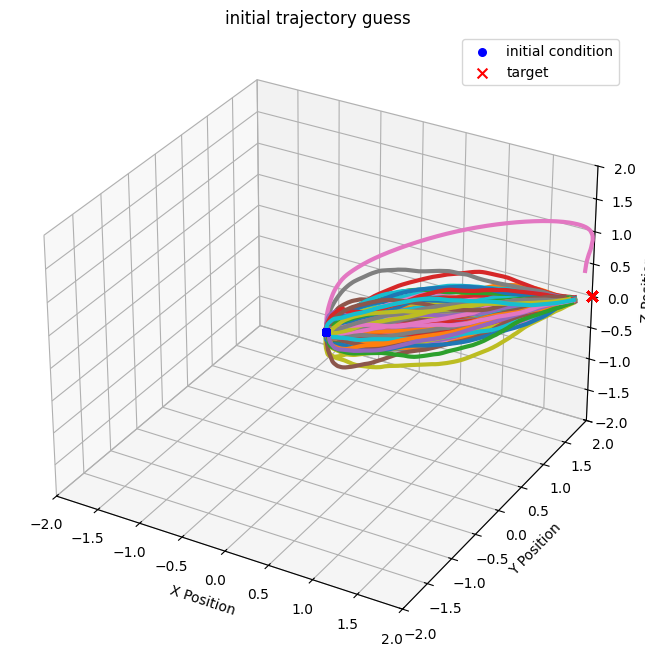

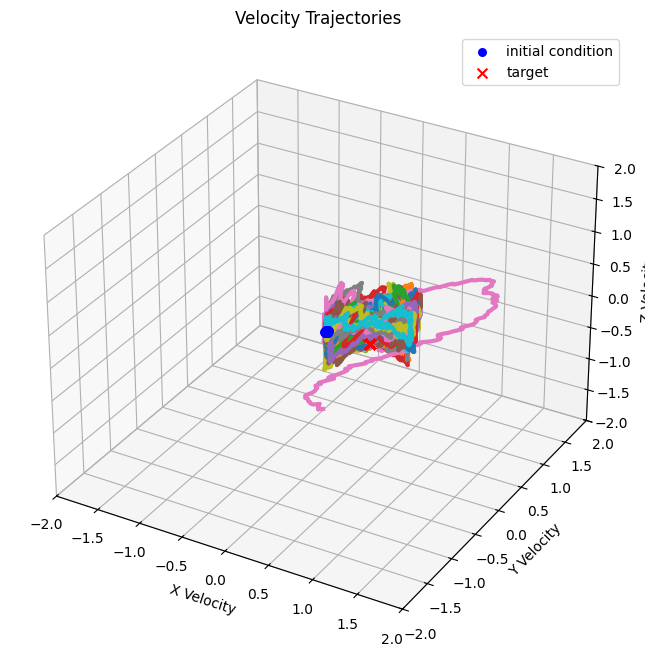

In [10]:
z_traj = generate_trajectory(u_true, z0, nt, return_full_trajectory=True)

plot_position_trajectories(z_traj.detach(), z_target, 'initial trajectory guess', plot_velocity=True)

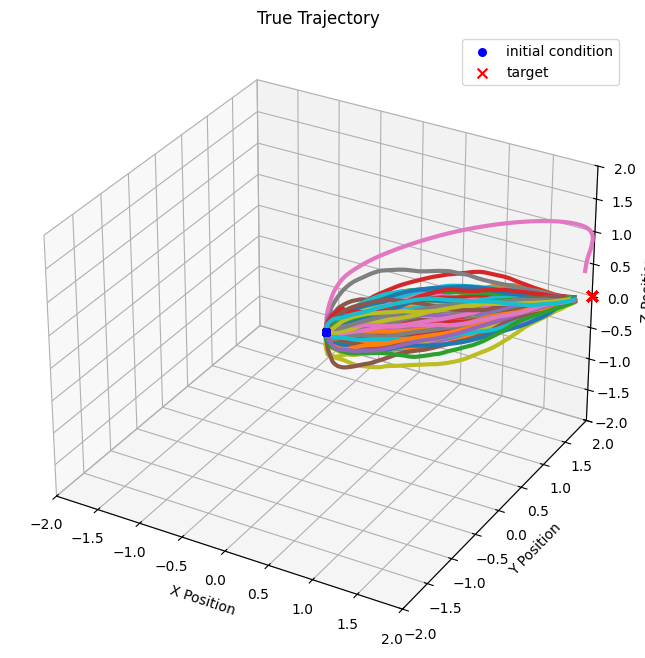

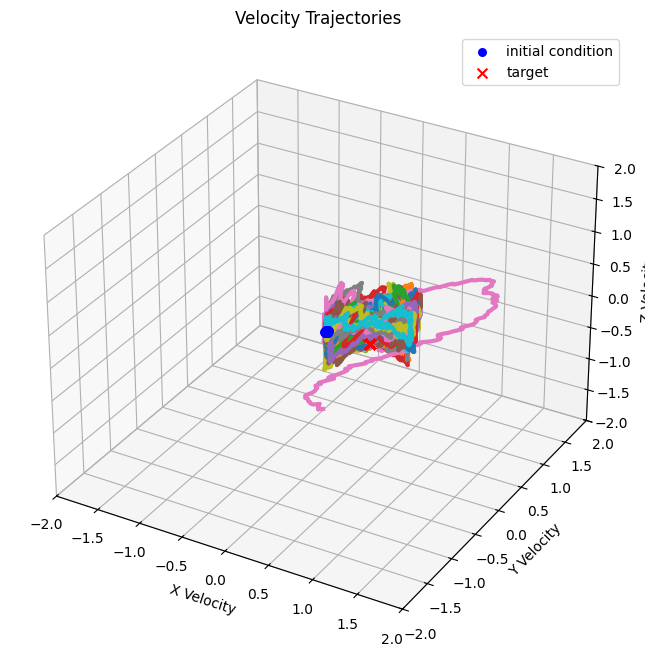

In [11]:
# detach variables
u_true = u_true.detach()
z0 = z0.detach()

z_traj = generate_trajectory(u_true, z0, nt, return_full_trajectory=True)

plot_position_trajectories(z_traj.detach(), z_target, 'True Trajectory', plot_velocity=True)

## Implicit Neural Network (INN) Implementation

In [9]:
# create implicit network architecture
class ImplicitNet(torch.nn.Module):
    def __init__(self, state_dim=12, control_dim=4, hidden_dim=100, alpha = 1e-1, max_iters=int(2.5e2), tol=1e-2, tracked_iters=5):
        super(ImplicitNet, self).__init__()

        # define network architecture
        self.control_dim = control_dim
        self.state_dim = state_dim

        self.fc1 = torch.nn.Linear(state_dim+1, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, state_dim) # value function outputs a scalar
        self.relu = torch.nn.ReLU()
        self.leaky_relu = torch.nn.LeakyReLU(negative_slope=0.1)

        self.alpha = alpha
        self.max_iters = max_iters
        self.tol = tol
        self.tracked_iters = tracked_iters 

    def p_net(self, t, z):
        ''' Neural network for the value function p(x, t)'''
        batch_size = z.shape[0]
        t = t * torch.ones(batch_size,1)
        zt = torch.cat((z, t), dim=1)
        x = self.relu(self.fc1(zt))
        x = self.relu(self.fc2(x))
        p = self.fc3(x)

        return p

    def T(self, u, x, t):

        batch_size = x.shape[0]
        t = torch.ones(1)*t
        
        assert t.shape == (1,)
        assert x.shape == (batch_size, self.state_dim)

        grad_H_u_val = compute_grad_H_u(t, x, u, self.p_net(t,x)) # derivative of H w.r.t. u
        assert grad_H_u_val.shape == u.shape
        return u - self.alpha * grad_H_u_val

    def anderson(self, u0, x, t, m=5, beta=0.5, lam=1.0e-6):
        """
        Fixed-Point Iteration with Anderson acceleration 

        Parameters:
            u0: Initial guess
            x: State vector in PDE-constrained dynamics
            t: Time
            m: Number of previous iterations to use in least-squares 
               optimization problem
            beta: Parameter in Anderson acceleration iteration
            lam: Regularization parameter

        Return:
            Fixed point of T_eval and number of iterations
        """
        batch_sz, dim = u0.shape
        u_hist = torch.zeros(batch_sz, m, dim, dtype=u0.dtype, device=u0.device)
        T_hist = torch.zeros(batch_sz, m, dim, dtype=u0.dtype, device=u0.device)
        u_hist[:,0] = u0.view(batch_sz, -1)
        T_hist[:,0] = self.T(u0, x, t).view(batch_sz,-1)
        u_hist[:,1] = T_hist[:,0]
        T_hist[:,1] = self.T(T_hist[:,0].view_as(u0), x, t).view(batch_sz,-1)
        H = torch.zeros(batch_sz, m+1, m+1, dtype=u0.dtype, device=u0.device)
        H[:,0,1:] = 1
        H[:,1:,0] = 1
        Batch_RHS = torch.zeros(batch_sz, m+1, 1, dtype=u0.dtype, device=u0.device)
        Batch_RHS[:,0] = 1 

        res_k = ((T_hist[:,0] - u_hist[:,0]).norm().item()) / (1.0e-9 + T_hist[:,0].norm().item())
        k = 1
        res_k = ((T_hist[:,k%m] - u_hist[:,k%m]).norm().item()) / (1.0e-9 + T_hist[:,k%m].norm().item())
        k += 1
        while (res_k > self.tol and k < self.max_iters):
            M = min(k,m)
            G = T_hist[:,:M] - u_hist[:,:M]
            H[:,1:(M+1),1:(M+1)] = torch.bmm(G, G.transpose(1,2)) + lam*torch.eye(M, dtype=u0.dtype, device=u0.device)[None]

            #Solve for alpha
            alpha = None
            try:
                alpha = torch.linalg.solve(H[:,:(M+1),:(M+1)], Batch_RHS[:,:(M+1)])[:,1:(M+1),0]#Result is batch_sz x n
            except RuntimeError:#If matrix is singular solve using QR least squares
                alpha = torch.linalg.lstsq(H[:,:(M+1),:(M+1)], Batch_RHS[:,:(M+1)])[0][:,1:(M+1)]

            #Update data structures
            u_hist[:,k%m] = (1-beta)*((alpha[:,None]@u_hist[:,:M])[:,0]) + beta*((alpha[:,None]@T_hist[:,:M])[:,0])
            T_hist[:,k%m] = self.T(u_hist[:,k%m].view_as(u0), x, t).view(batch_sz, -1)
            res_k = ((T_hist[:,k%m] - u_hist[:,k%m]).norm().item()) / (1.0e-9 + T_hist[:,k%m].norm().item())
            k += 1

        return u_hist[:,k%m].view_as(u0), k

    def forward(self, x, t, verbose=False):
        
        batch_size = x.shape[0]
        t = torch.ones(1)*t

        u = torch.zeros(batch_size, self.control_dim)

        with torch.no_grad():
            #Banach fixed-point iteration
            """
            for i in range(self.max_iters):
                u_old = u.clone()
                u = self.T(u, x, t)
                assert u.shape == (batch_size, control_dim)
                # compute maximum residual norm over batches
                max_res_norm = torch.norm(u - u_old, dim=1).max()

                if verbose:
                    print('iter %d, max res norm %1.5e' % (i+1, max_res_norm))
                    if max_res_norm < self.tol:
                        print('converged in %d iterations with res norm %1.5e' % (i+1, max_res_norm))
                        converged = True
                        break

                    if i == self.max_iters-1 and max_res_norm > self.tol:
                        print('did not converge in %d iterations with res norm %1.5e' % (i+1, max_res_norm))
            """

            #Anderson acceleration fixed-point iteration
            u, itr = self.anderson(u, x, t, beta=0.8)
        
            if verbose:
                if itr >= self.max_iters:
                    print("Anderson acceleration stopped max_iter iterations, did not converge")
                else:
                    print("Anderson acceleration converged after " + str(k) + " iterations")
        
        if self.training:
            for i in range(self.tracked_iters):
                u = self.T(u, x, t)
            output = self.T(u, x, t)
            return output
        else:
            output = u
            return output

Initial Guesses for Position and Velocity Trajectories

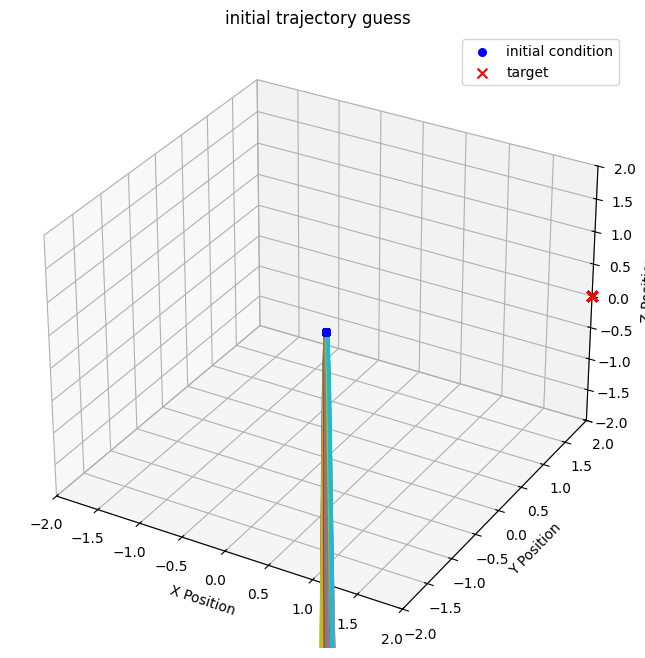

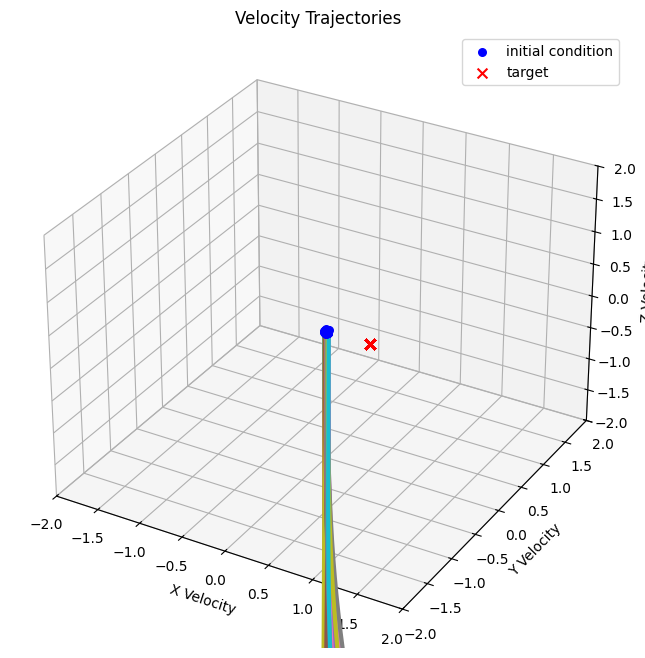

In [10]:
u_net_implicit = ImplicitNet(hidden_dim = 100, max_iters=100, tol=1e-1)
z_traj = generate_trajectory(u_net_implicit, z0, nt, return_full_trajectory=True)
plot_position_trajectories(z_traj.detach(), z_target, 'initial trajectory guess', plot_velocity=True)

C:\Users\egelp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\egelp\AppData\Local\Temp\ipykernel_22968\1416134357.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  grad_norm = torch.sqrt(torch.tensor(grad_norm))


iter 1, loss 9.512e+02, grad 7.230e+03, L 3.757e-01, G 1.902e+02, time: 2.855e+00, lr: 1.000e-02
iter 2, loss 1.014e+02, grad 1.175e+03, L 6.549e-01, G 2.016e+01, time: 3.051e+00, lr: 1.000e-02
iter 3, loss 6.311e+01, grad 1.170e+03, L 1.743e+00, G 1.227e+01, time: 2.888e+00, lr: 1.000e-02
iter 4, loss 3.103e+01, grad 2.023e+02, L 1.069e+00, G 5.992e+00, time: 3.091e+00, lr: 1.000e-02
iter 5, loss 5.428e+01, grad 7.530e+02, L 1.364e+00, G 1.058e+01, time: 2.889e+00, lr: 1.000e-02
iter 6, loss 3.823e+01, grad 4.836e+02, L 9.096e-01, G 7.465e+00, time: 3.105e+00, lr: 1.000e-02
iter 7, loss 2.757e+01, grad 2.153e+02, L 7.898e-01, G 5.355e+00, time: 3.119e+00, lr: 1.000e-02
iter 8, loss 2.816e+01, grad 3.166e+02, L 8.333e-01, G 5.464e+00, time: 2.831e+00, lr: 1.000e-02
iter 9, loss 2.499e+01, grad 3.528e+02, L 8.255e-01, G 4.832e+00, time: 3.039e+00, lr: 1.000e-02
iter 10, loss 1.671e+01, grad 1.809e+02, L 7.334e-01, G 3.196e+00, time: 3.124e+00, lr: 1.000e-02
iter 11, loss 1.200e+01, grad

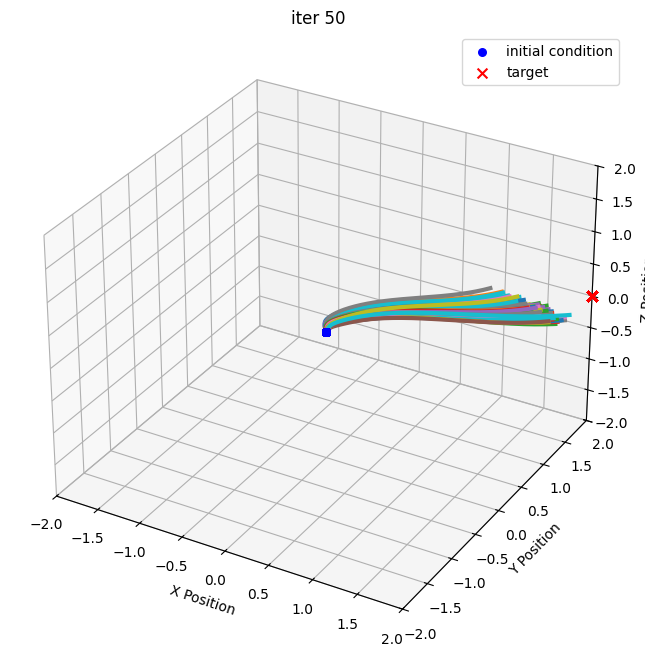

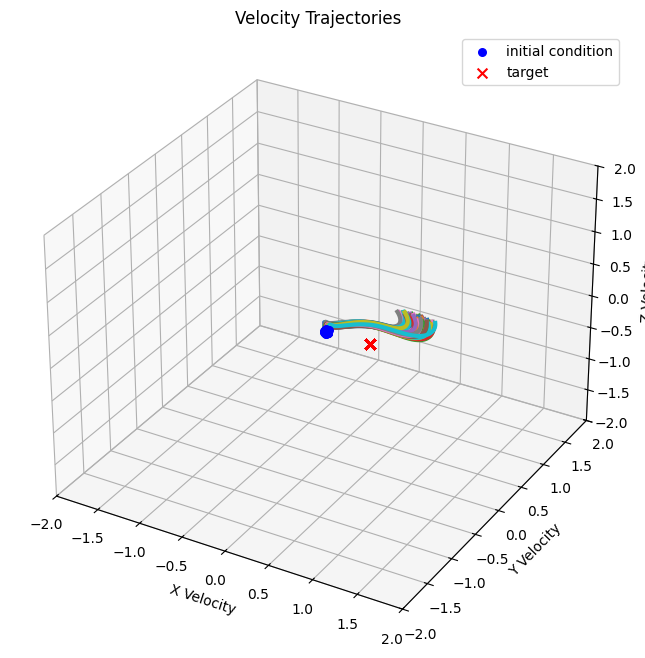

iter 50, loss 5.395e+00, grad 2.102e+01, L 7.740e-01, G 9.242e-01, time: 5.487e+00, lr: 1.000e-02
iter 51, loss 5.260e+00, grad 1.500e+01, L 7.772e-01, G 8.966e-01, time: 3.029e+00, lr: 1.000e-02
iter 52, loss 5.200e+00, grad 9.061e+00, L 7.727e-01, G 8.854e-01, time: 2.973e+00, lr: 1.000e-02
iter 53, loss 5.251e+00, grad 2.369e+01, L 7.765e-01, G 8.949e-01, time: 2.979e+00, lr: 1.000e-02
iter 54, loss 5.115e+00, grad 1.762e+01, L 7.497e-01, G 8.731e-01, time: 2.943e+00, lr: 1.000e-02
iter 55, loss 5.068e+00, grad 3.416e+01, L 7.371e-01, G 8.662e-01, time: 3.166e+00, lr: 1.000e-02
iter 56, loss 4.953e+00, grad 6.528e+00, L 7.530e-01, G 8.400e-01, time: 3.009e+00, lr: 1.000e-02
iter 57, loss 4.807e+00, grad 9.047e+00, L 7.569e-01, G 8.101e-01, time: 3.364e+00, lr: 1.000e-02
iter 58, loss 4.769e+00, grad 1.089e+01, L 7.539e-01, G 8.030e-01, time: 2.951e+00, lr: 1.000e-02
iter 59, loss 4.716e+00, grad 3.179e+01, L 7.319e-01, G 7.969e-01, time: 3.141e+00, lr: 1.000e-02
iter 60, loss 4.600e

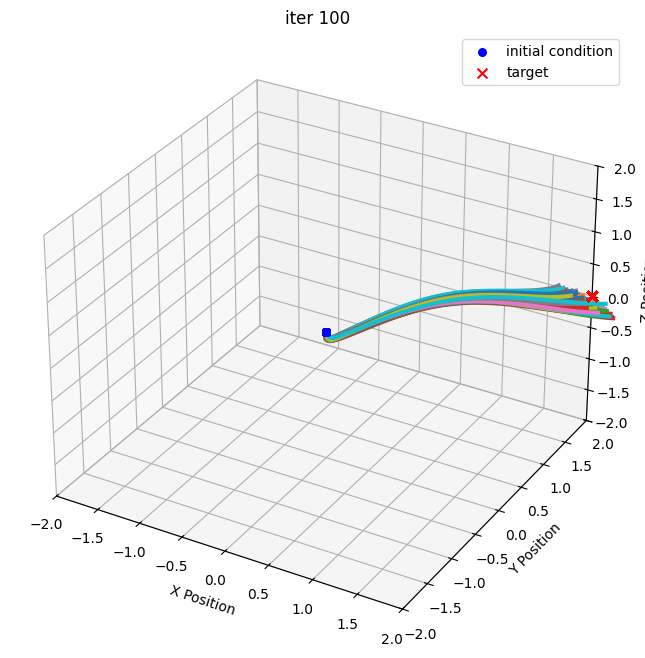

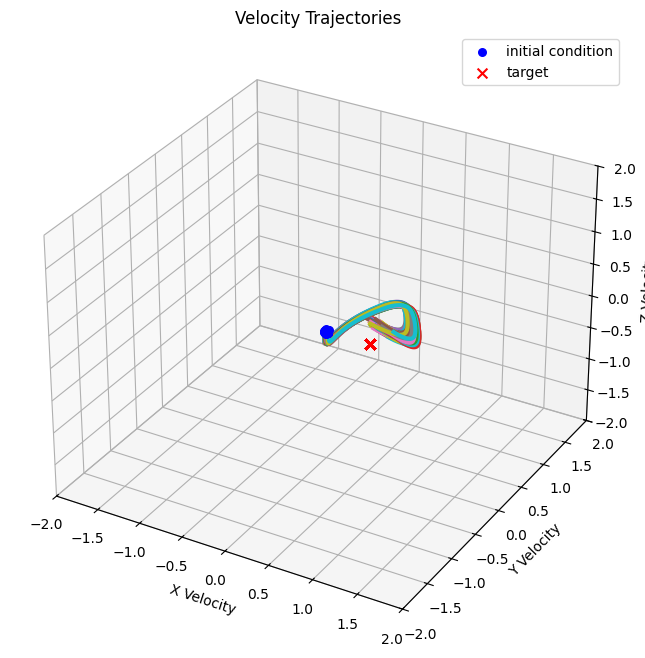

iter 100, loss 2.349e+00, grad 3.674e+01, L 1.015e+00, G 2.667e-01, time: 5.505e+00, lr: 9.000e-03
iter 101, loss 2.164e+00, grad 1.901e+01, L 1.037e+00, G 2.254e-01, time: 3.278e+00, lr: 9.000e-03
iter 102, loss 2.262e+00, grad 3.435e+01, L 1.054e+00, G 2.416e-01, time: 3.207e+00, lr: 9.000e-03
iter 103, loss 2.126e+00, grad 1.217e+01, L 1.043e+00, G 2.167e-01, time: 3.239e+00, lr: 9.000e-03
iter 104, loss 2.226e+00, grad 2.891e+01, L 1.032e+00, G 2.390e-01, time: 2.930e+00, lr: 9.000e-03
iter 105, loss 2.155e+00, grad 1.671e+01, L 1.046e+00, G 2.219e-01, time: 3.122e+00, lr: 9.000e-03
iter 106, loss 2.134e+00, grad 1.112e+01, L 1.069e+00, G 2.131e-01, time: 3.067e+00, lr: 9.000e-03
iter 107, loss 2.159e+00, grad 2.687e+01, L 1.085e+00, G 2.147e-01, time: 3.253e+00, lr: 9.000e-03
iter 108, loss 2.105e+00, grad 1.180e+01, L 1.080e+00, G 2.050e-01, time: 3.080e+00, lr: 9.000e-03
iter 109, loss 2.126e+00, grad 2.379e+01, L 1.067e+00, G 2.118e-01, time: 3.209e+00, lr: 9.000e-03
iter 110, 

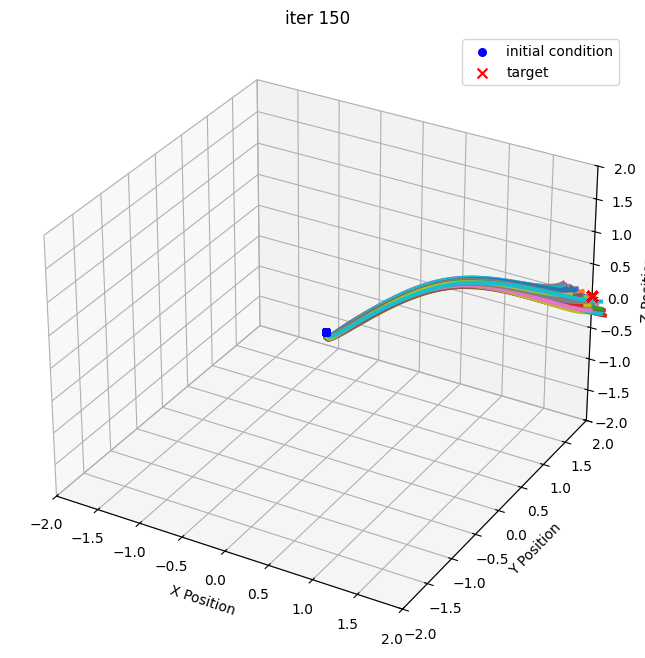

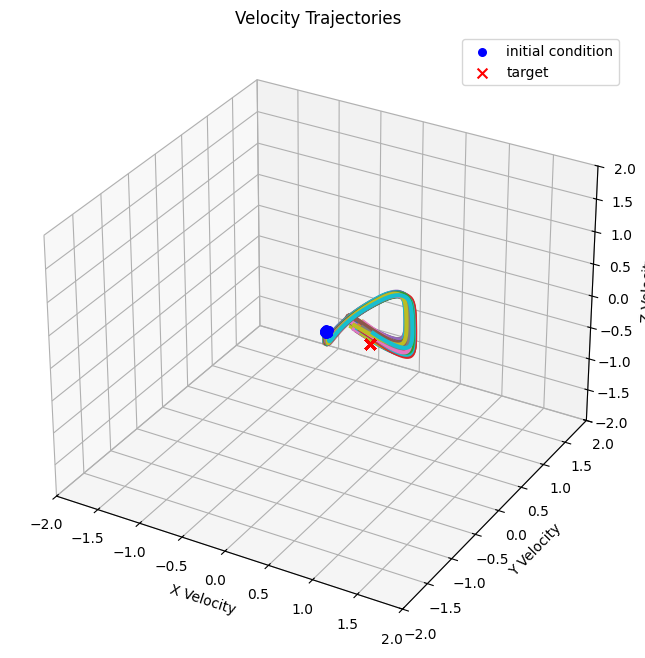

iter 150, loss 1.948e+00, grad 4.695e+00, L 1.168e+00, G 1.560e-01, time: 5.775e+00, lr: 6.561e-03
iter 151, loss 1.965e+00, grad 1.277e+01, L 1.166e+00, G 1.597e-01, time: 3.083e+00, lr: 6.561e-03
iter 152, loss 1.944e+00, grad 1.682e+01, L 1.172e+00, G 1.544e-01, time: 3.085e+00, lr: 6.561e-03
iter 153, loss 1.933e+00, grad 3.433e+00, L 1.175e+00, G 1.516e-01, time: 3.116e+00, lr: 6.561e-03
iter 154, loss 1.938e+00, grad 1.433e+01, L 1.178e+00, G 1.520e-01, time: 3.009e+00, lr: 6.561e-03
iter 155, loss 1.973e+00, grad 8.293e+00, L 1.173e+00, G 1.600e-01, time: 2.923e+00, lr: 6.561e-03
iter 156, loss 1.925e+00, grad 7.364e+00, L 1.170e+00, G 1.510e-01, time: 3.144e+00, lr: 5.905e-03
iter 157, loss 1.936e+00, grad 3.168e+00, L 1.170e+00, G 1.530e-01, time: 3.034e+00, lr: 5.905e-03
iter 158, loss 1.938e+00, grad 1.112e+01, L 1.175e+00, G 1.526e-01, time: 3.111e+00, lr: 5.905e-03
iter 159, loss 1.942e+00, grad 6.138e+00, L 1.181e+00, G 1.522e-01, time: 2.954e+00, lr: 5.905e-03
iter 160, 

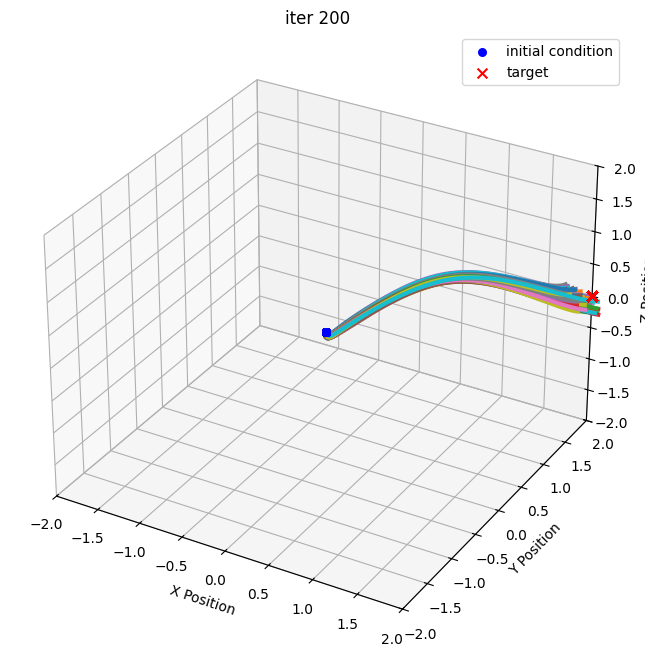

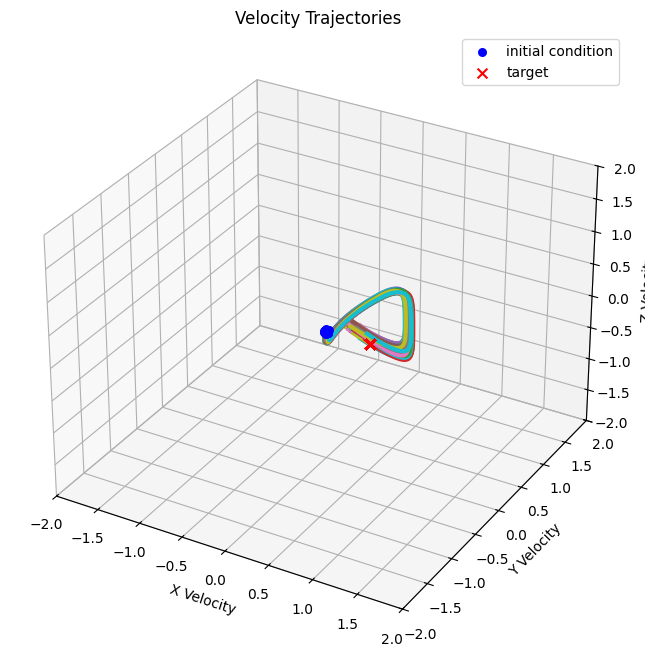

iter 200, loss 1.879e+00, grad 6.386e+00, L 1.204e+00, G 1.351e-01, time: 5.182e+00, lr: 4.783e-03
iter 201, loss 1.893e+00, grad 5.376e+00, L 1.207e+00, G 1.373e-01, time: 2.831e+00, lr: 4.783e-03
iter 202, loss 1.921e+00, grad 8.484e+00, L 1.206e+00, G 1.430e-01, time: 2.966e+00, lr: 4.783e-03
iter 203, loss 1.877e+00, grad 7.726e+00, L 1.204e+00, G 1.345e-01, time: 2.752e+00, lr: 4.783e-03
iter 204, loss 1.879e+00, grad 5.278e+00, L 1.203e+00, G 1.351e-01, time: 2.691e+00, lr: 4.783e-03
iter 205, loss 1.887e+00, grad 8.122e+00, L 1.203e+00, G 1.369e-01, time: 2.866e+00, lr: 4.305e-03
iter 206, loss 1.893e+00, grad 5.343e+00, L 1.205e+00, G 1.376e-01, time: 2.809e+00, lr: 4.305e-03
iter 207, loss 1.890e+00, grad 2.094e+00, L 1.210e+00, G 1.360e-01, time: 2.937e+00, lr: 4.305e-03
iter 208, loss 1.890e+00, grad 7.052e-01, L 1.209e+00, G 1.363e-01, time: 2.758e+00, lr: 4.305e-03
iter 209, loss 1.860e+00, grad 3.328e+00, L 1.209e+00, G 1.302e-01, time: 3.161e+00, lr: 4.305e-03
iter 210, 

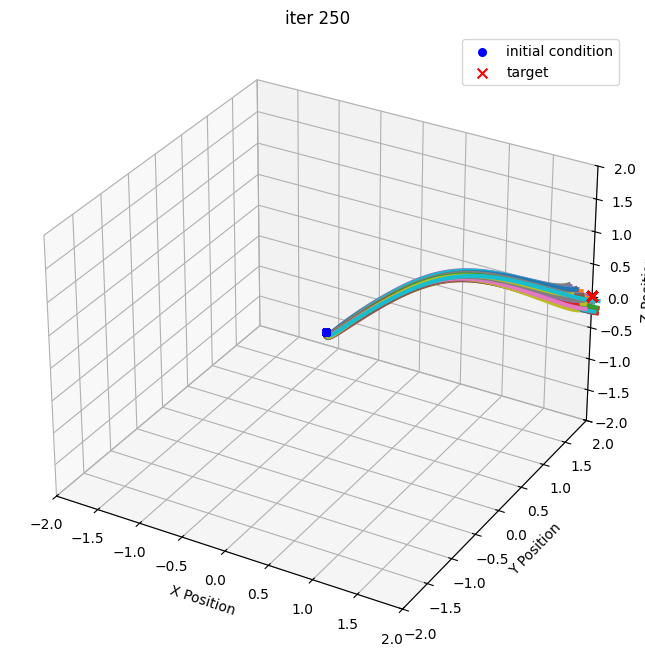

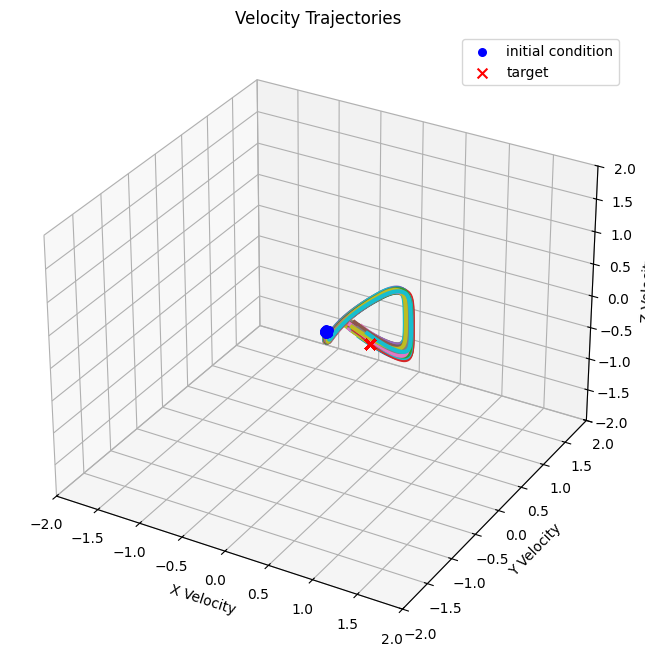

iter 250, loss 1.866e+00, grad 1.018e+00, L 1.218e+00, G 1.295e-01, time: 5.930e+00, lr: 2.288e-03
iter 251, loss 1.862e+00, grad 4.155e+00, L 1.218e+00, G 1.287e-01, time: 3.101e+00, lr: 2.288e-03
iter 252, loss 1.866e+00, grad 2.293e+00, L 1.217e+00, G 1.298e-01, time: 3.247e+00, lr: 2.288e-03
iter 253, loss 1.882e+00, grad 2.040e+00, L 1.217e+00, G 1.328e-01, time: 3.231e+00, lr: 2.288e-03
iter 254, loss 1.880e+00, grad 2.515e+00, L 1.217e+00, G 1.326e-01, time: 3.410e+00, lr: 2.288e-03
iter 255, loss 1.861e+00, grad 1.187e+00, L 1.216e+00, G 1.289e-01, time: 3.212e+00, lr: 2.288e-03
iter 256, loss 1.880e+00, grad 3.062e+00, L 1.217e+00, G 1.326e-01, time: 3.694e+00, lr: 2.059e-03
iter 257, loss 1.867e+00, grad 3.135e+00, L 1.216e+00, G 1.302e-01, time: 3.592e+00, lr: 2.059e-03
iter 258, loss 1.886e+00, grad 1.759e+00, L 1.218e+00, G 1.336e-01, time: 2.882e+00, lr: 2.059e-03
iter 259, loss 1.885e+00, grad 1.563e+00, L 1.218e+00, G 1.334e-01, time: 2.872e+00, lr: 2.059e-03
iter 260, 

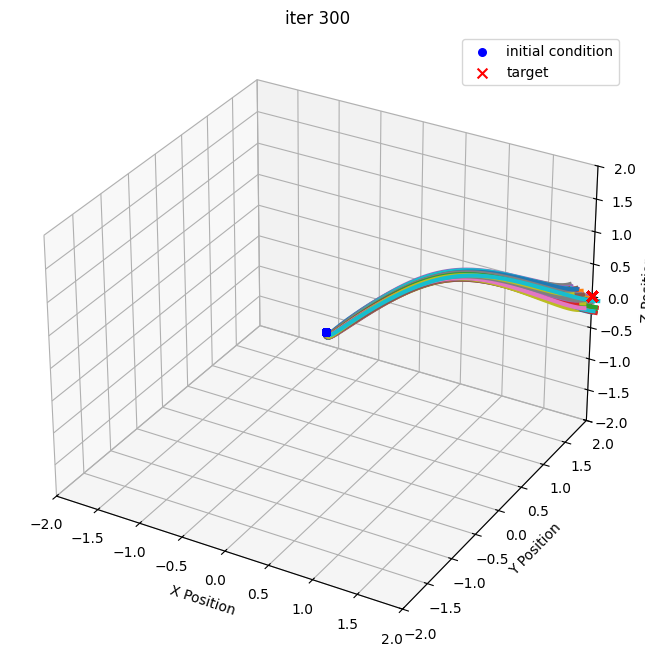

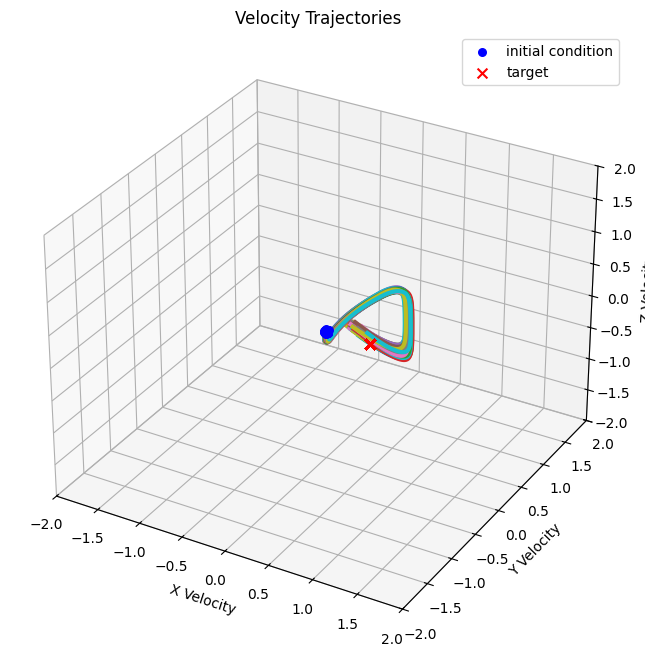

iter 300, loss 1.856e+00, grad 2.266e+00, L 1.222e+00, G 1.270e-01, time: 6.012e+00, lr: 1.094e-03
iter 301, loss 1.870e+00, grad 1.656e+00, L 1.222e+00, G 1.295e-01, time: 3.153e+00, lr: 9.848e-04
iter 302, loss 1.857e+00, grad 1.721e+00, L 1.221e+00, G 1.273e-01, time: 3.252e+00, lr: 9.848e-04
iter 303, loss 1.854e+00, grad 5.483e+00, L 1.222e+00, G 1.264e-01, time: 2.959e+00, lr: 9.848e-04
iter 304, loss 1.870e+00, grad 2.995e+00, L 1.222e+00, G 1.296e-01, time: 2.839e+00, lr: 9.848e-04
iter 305, loss 1.840e+00, grad 3.619e+00, L 1.224e+00, G 1.233e-01, time: 3.078e+00, lr: 9.848e-04
iter 306, loss 1.853e+00, grad 1.102e+00, L 1.223e+00, G 1.260e-01, time: 2.761e+00, lr: 9.848e-04
iter 307, loss 1.862e+00, grad 2.033e+00, L 1.223e+00, G 1.278e-01, time: 2.838e+00, lr: 9.848e-04
iter 308, loss 1.859e+00, grad 1.303e+00, L 1.222e+00, G 1.274e-01, time: 3.088e+00, lr: 9.848e-04
iter 309, loss 1.848e+00, grad 4.784e+00, L 1.223e+00, G 1.251e-01, time: 3.247e+00, lr: 9.848e-04
iter 310, 

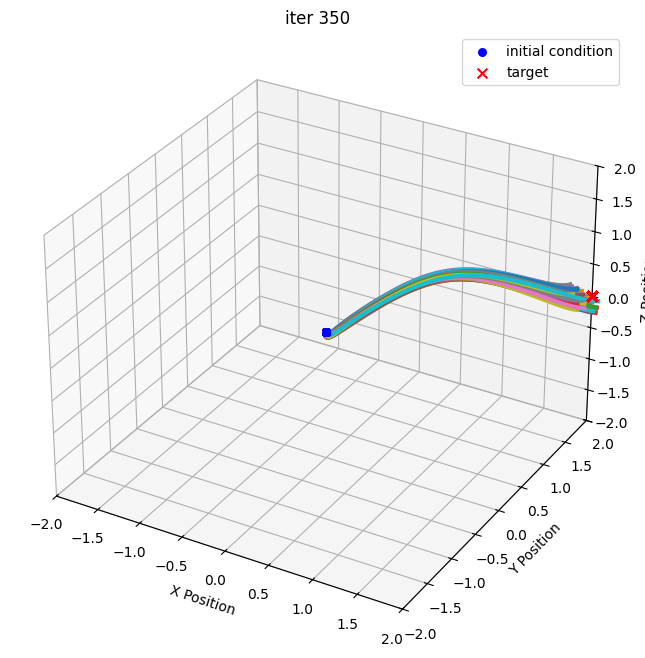

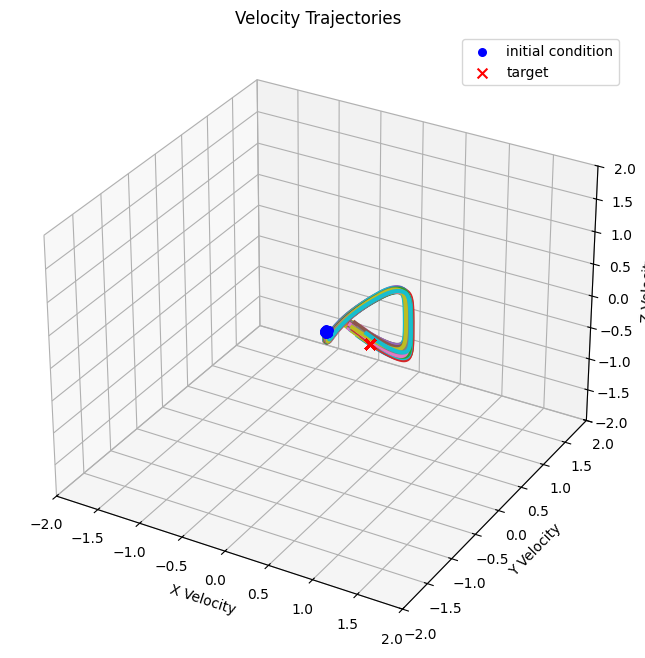

iter 350, loss 1.845e+00, grad 1.171e+00, L 1.224e+00, G 1.242e-01, time: 5.874e+00, lr: 4.710e-04
iter 351, loss 1.887e+00, grad 1.429e+00, L 1.226e+00, G 1.322e-01, time: 3.267e+00, lr: 4.710e-04
iter 352, loss 1.853e+00, grad 6.261e-01, L 1.223e+00, G 1.260e-01, time: 3.086e+00, lr: 4.710e-04
iter 353, loss 1.870e+00, grad 1.014e+00, L 1.222e+00, G 1.297e-01, time: 3.305e+00, lr: 4.710e-04
iter 354, loss 1.866e+00, grad 4.319e+00, L 1.223e+00, G 1.285e-01, time: 3.239e+00, lr: 4.239e-04
iter 355, loss 1.846e+00, grad 1.062e+00, L 1.223e+00, G 1.246e-01, time: 3.100e+00, lr: 4.239e-04
iter 356, loss 1.868e+00, grad 1.986e+00, L 1.224e+00, G 1.289e-01, time: 3.236e+00, lr: 4.239e-04
iter 357, loss 1.873e+00, grad 3.044e+00, L 1.221e+00, G 1.304e-01, time: 3.266e+00, lr: 4.239e-04
iter 358, loss 1.868e+00, grad 5.060e-01, L 1.222e+00, G 1.292e-01, time: 3.022e+00, lr: 4.239e-04
iter 359, loss 1.868e+00, grad 2.511e+00, L 1.224e+00, G 1.288e-01, time: 3.172e+00, lr: 4.239e-04
iter 360, 

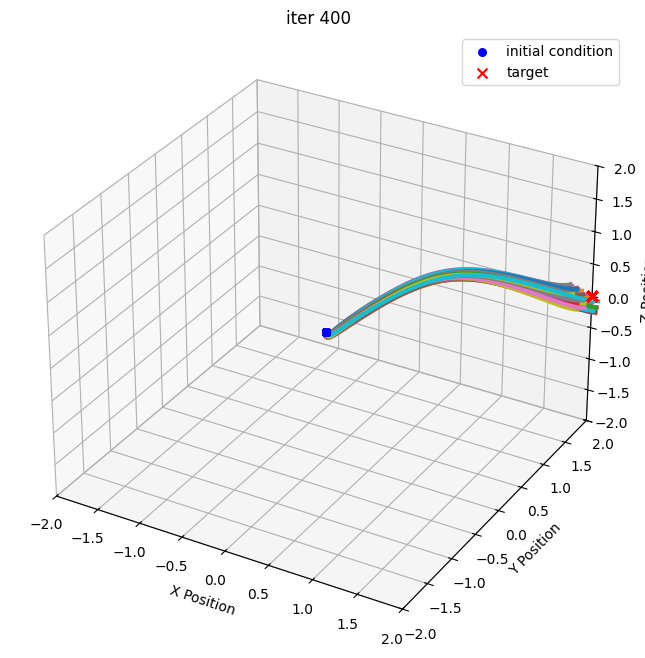

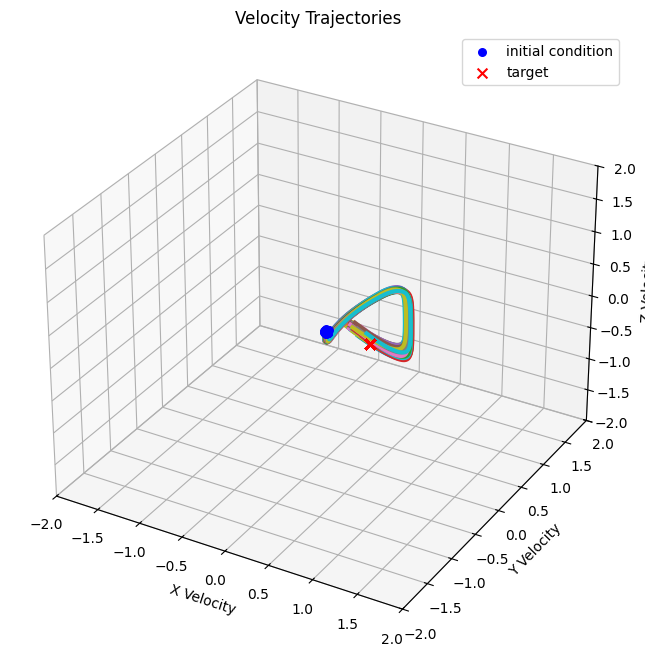

iter 400, loss 1.859e+00, grad 1.894e+00, L 1.227e+00, G 1.265e-01, time: 5.541e+00, lr: 2.028e-04
iter 401, loss 1.859e+00, grad 3.299e+00, L 1.226e+00, G 1.266e-01, time: 2.877e+00, lr: 2.028e-04
iter 402, loss 1.853e+00, grad 2.340e+00, L 1.227e+00, G 1.253e-01, time: 2.878e+00, lr: 1.825e-04
iter 403, loss 1.867e+00, grad 1.216e+00, L 1.226e+00, G 1.281e-01, time: 2.970e+00, lr: 1.825e-04
iter 404, loss 1.853e+00, grad 1.107e+00, L 1.226e+00, G 1.254e-01, time: 3.064e+00, lr: 1.825e-04
iter 405, loss 1.847e+00, grad 2.511e+00, L 1.225e+00, G 1.245e-01, time: 3.381e+00, lr: 1.825e-04
iter 406, loss 1.845e+00, grad 2.089e+00, L 1.225e+00, G 1.240e-01, time: 4.398e+00, lr: 1.825e-04
iter 407, loss 1.863e+00, grad 2.823e+00, L 1.224e+00, G 1.278e-01, time: 3.480e+00, lr: 1.825e-04
iter 408, loss 1.842e+00, grad 1.276e+00, L 1.224e+00, G 1.237e-01, time: 3.081e+00, lr: 1.642e-04
iter 409, loss 1.850e+00, grad 1.804e+00, L 1.225e+00, G 1.250e-01, time: 3.011e+00, lr: 1.642e-04
iter 410, 

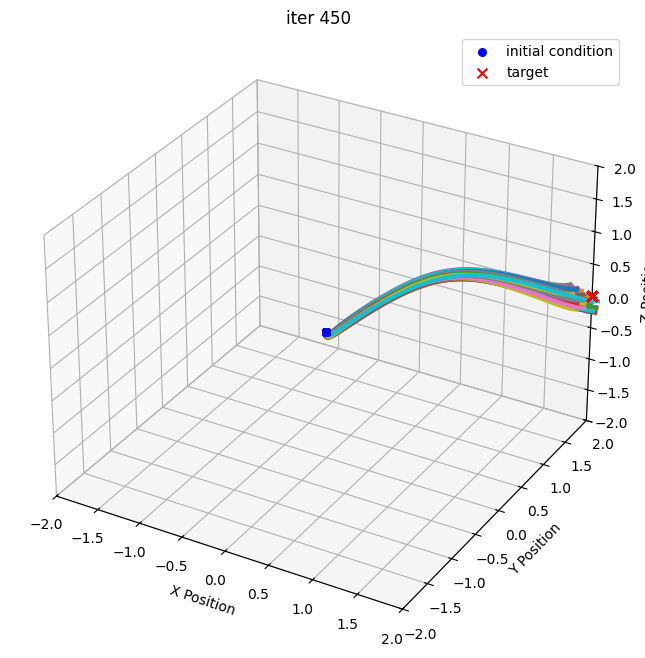

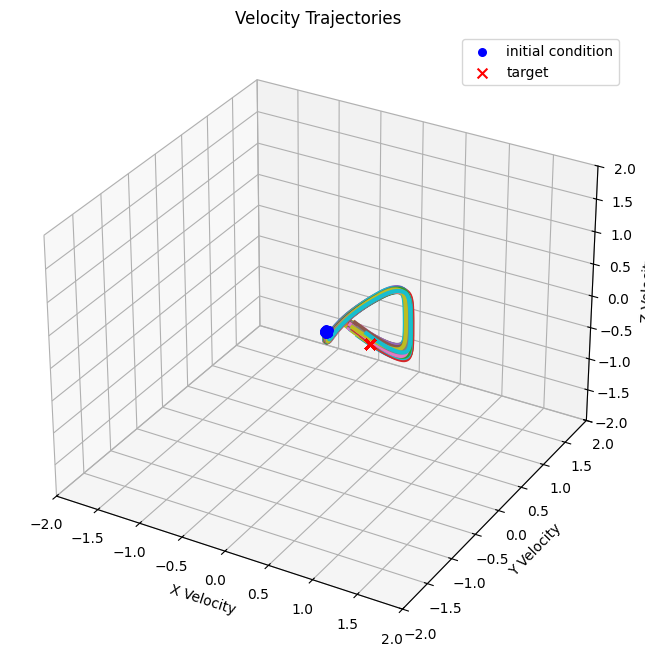

iter 450, loss 1.870e+00, grad 1.329e+00, L 1.224e+00, G 1.291e-01, time: 7.083e+00, lr: 8.728e-05
iter 451, loss 1.842e+00, grad 2.316e+00, L 1.223e+00, G 1.239e-01, time: 3.270e+00, lr: 7.855e-05
iter 452, loss 1.859e+00, grad 9.764e-01, L 1.225e+00, G 1.267e-01, time: 3.394e+00, lr: 7.855e-05
iter 453, loss 1.851e+00, grad 1.836e+00, L 1.224e+00, G 1.255e-01, time: 3.118e+00, lr: 7.855e-05
iter 454, loss 1.873e+00, grad 2.213e+00, L 1.227e+00, G 1.293e-01, time: 3.032e+00, lr: 7.855e-05
iter 455, loss 1.858e+00, grad 1.968e+00, L 1.224e+00, G 1.267e-01, time: 3.070e+00, lr: 7.855e-05
iter 456, loss 1.861e+00, grad 2.834e+00, L 1.225e+00, G 1.272e-01, time: 3.331e+00, lr: 7.855e-05
iter 457, loss 1.855e+00, grad 1.988e+00, L 1.225e+00, G 1.260e-01, time: 2.950e+00, lr: 7.070e-05
iter 458, loss 1.849e+00, grad 2.098e+00, L 1.224e+00, G 1.250e-01, time: 3.592e+00, lr: 7.070e-05
iter 459, loss 1.868e+00, grad 2.016e+00, L 1.224e+00, G 1.288e-01, time: 3.782e+00, lr: 7.070e-05
iter 460, 

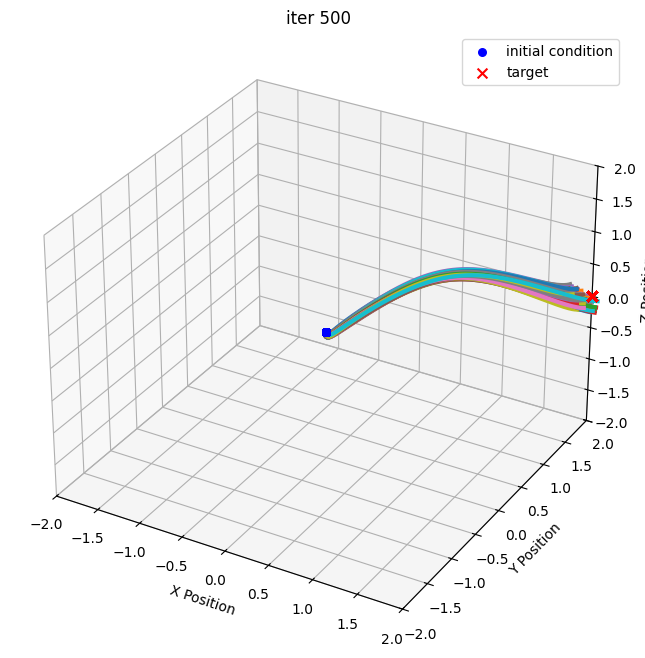

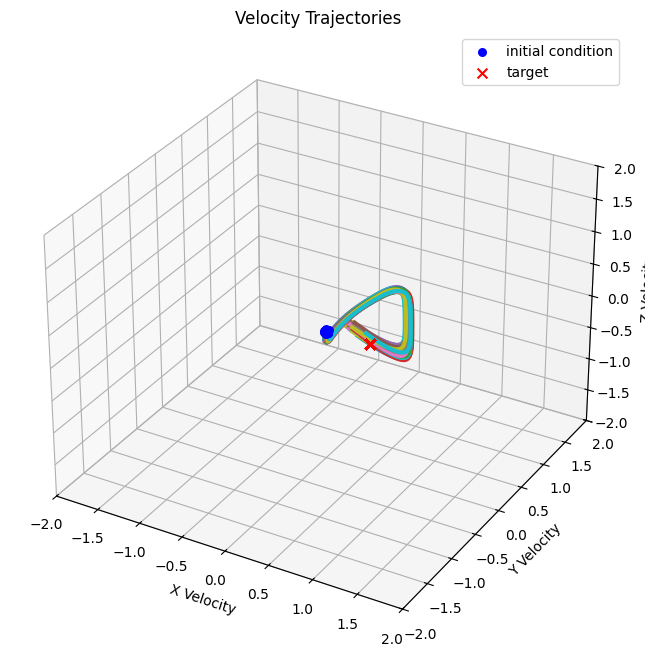

iter 500, loss 1.852e+00, grad 2.438e+00, L 1.224e+00, G 1.257e-01, time: 5.622e+00, lr: 3.381e-05


In [11]:
optimizer = torch.optim.Adam(u_net_implicit.parameters(), lr=1e-2)
# reduce on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=5, verbose=True)
u_net_implicit.train()

plot_frequency = 50

best_loss = 1e10
max_epochs = int(500)
batch_size = 100

for i in range(1, max_epochs+1):

    start_time = time.time()
    optimizer.zero_grad()

    # sample z0 from \rho0 (normal distribution for positions and 0 velocity)
    z0_batch = sample_initial_condition(batch_size, state_dim, device=device)

    # for the first 20 epochs, use 10 iterations for finding the fixed point, then use 100 iterations for the next 30 epochs
    if i < 20: 
        u_net_implicit.max_epochs = 10
    elif i< 50:
        u_net_implicit.max_epochs = 100
    # else:
    #     u_net_implicit.max_iters = int(1e3)
    loss, running_cost, terminal_cost = compute_loss(u_net_implicit, z0_batch, nt)

    # save best model 
    if loss < best_loss:
        best_loss = loss
        best_net = u_net_implicit.state_dict()
        torch.save(best_net, 'best_implicit_model.pth')

    # plot every plot_frequency iterations
    if i % plot_frequency == 0:
        z_traj = generate_trajectory(u_net_implicit, z0, nt, return_full_trajectory=True)
        plot_position_trajectories(z_traj.detach(), z_target, 'iter %d' % i, plot_velocity=True)
        
    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    # compute gradient norm of parameters 
    grad_norm = 0.0
    for param in u_net_implicit.parameters():
        if param.grad is not None:
            grad_norm += torch.norm(param.grad)**2
    grad_norm = torch.sqrt(torch.tensor(grad_norm))

    end_time = time.time()
    iter_time = end_time - start_time
    current_learning_rate = optimizer.param_groups[0]['lr']

    if i % 1 == 0:
        # print in %1.3e format
        print("iter %d, loss %.3e, grad %.3e, L %.3e, G %.3e, time: %.3e, lr: %1.3e" % (i, loss.item(), grad_norm.item(), running_cost.item(), terminal_cost.item(), iter_time, current_learning_rate))


Load Best Implicit Model

In [12]:
# load best implicit model
u_net_implicit.load_state_dict(torch.load('best_implicit_model.pth'))

C:\Users\egelp\AppData\Local\Temp\ipykernel_22968\2257185251.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_net_implicit.load_state_dict(torch.load('best_implicit_mod

<All keys matched successfully>

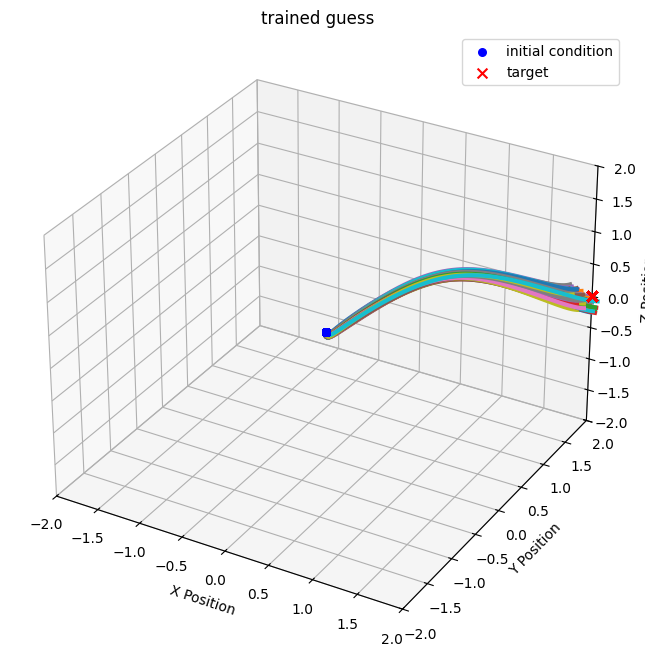

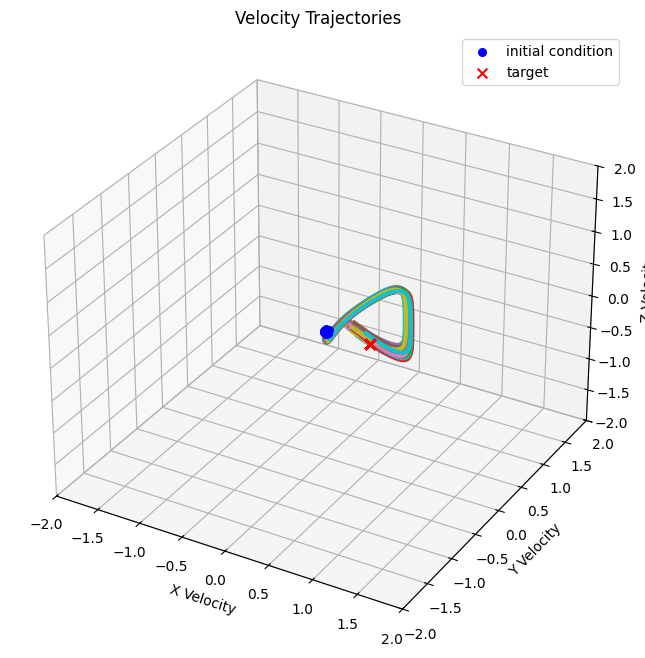

In [13]:
z_traj = generate_trajectory(u_net_implicit, z0, nt, return_full_trajectory=True)
plot_position_trajectories(z_traj.detach(), z_target, 'trained guess', plot_velocity=True)